<a href="https://colab.research.google.com/github/allan-f0101/Data-Science-projects/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [253]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split

from IPython.display import display
from matplotlib.colors import ListedColormap

In [254]:
import pandas as pd


df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
#Verificando a presença de valores faltantes
show1 = df_train.isnull().sum()
show2 = df_test.isnull().sum()
print(show1)
print()
print(show2)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [255]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [256]:
df_train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [257]:
#Visualizando a presença de duplicatas
N_samples = len(df_train)
perc_duplicated = float(df_train.duplicated().sum()) / N_samples
print(f"Duplicatas de treino: {100 * perc_duplicated:.3f}%")

N_samples2 = len(df_test)
perc_duplicated2 = float(df_test.duplicated().sum()) / N_samples2
print(f"Duplicatas de teste: {100 * perc_duplicated2:.3f}%")

Duplicatas de treino: 0.000%
Duplicatas de teste: 0.000%


In [258]:
#Drop de colunas desnecessárias

df_train.drop(['PassengerId', 'Ticket', 'Name'], inplace=True, axis=1, errors="ignore")
df_test.drop(['PassengerId', 'Ticket', 'Name'], inplace=True, axis=1, errors="ignore")

sex_map = {'male': 1, 'female': 0}
df_train['Sex'] = df_train['Sex'].map(sex_map)

df_train['Cabin'] = df_train['Cabin'].fillna("Unknown").astype(str).str[0]
df_test['Cabin'] = df_test['Cabin'].fillna("Unknown").astype(str).str[0]

In [259]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,U,S
1,1,1,0,38.0,1,0,71.2833,C,C
2,1,3,0,26.0,0,0,7.9250,U,S
3,1,1,0,35.0,1,0,53.1000,C,S
4,0,3,1,35.0,0,0,8.0500,U,S


In [260]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,34.5,0,0,7.8292,U,Q
1,3,female,47.0,1,0,7.0000,U,S
2,2,male,62.0,0,0,9.6875,U,Q
3,3,male,27.0,0,0,8.6625,U,S
4,3,female,22.0,1,1,12.2875,U,S


In [262]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,U,S
1,1,1,0,38.0,1,0,71.2833,C,C
2,1,3,0,26.0,0,0,7.9250,U,S
3,1,1,0,35.0,1,0,53.1000,C,S
4,0,3,1,35.0,0,0,8.0500,U,S


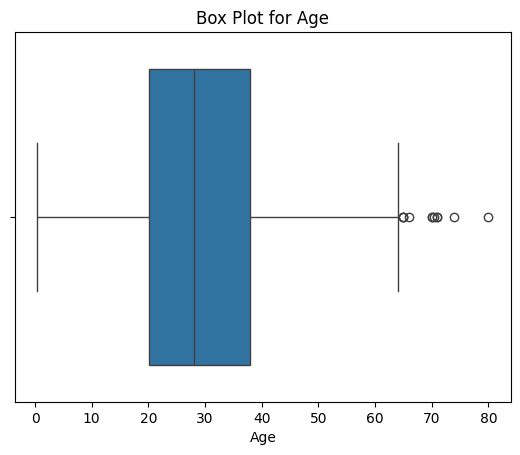

In [263]:
sns.boxplot(x=df_train['Age'])
plt.title("Box Plot for Age")
plt.show()

### Imputação dos dados

In [264]:
X = df_train.drop(columns=["Survived"], errors='ignore')
y = df_original["Survived"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

df_original = pd.read_csv('train.csv')

imp_mean = SimpleImputer(strategy='mean')
X_train[["Age", 'Fare']] = imp_mean.fit_transform(X_train[['Age', 'Fare']])
X_val[['Age', 'Fare']] = imp_mean.transform(X_val[['Age', 'Fare']])
df_test[['Age', 'Fare']] = imp_mean.transform(df_test[['Age', 'Fare']])

imp_mode = SimpleImputer(strategy='most_frequent')
X_train[['Embarked']] = imp_mode.fit_transform(X_train[['Embarked']])
X_val[["Embarked"]] = imp_mode.transform(X_val[["Embarked"]])
df_test[['Embarked']] = imp_mode.transform(df_test[['Embarked']])

def extrair_deck(cabine):
    if pd.isna(cabine):
        return "U"

    return str(cabine)[0]

X_train['Cabin'] = X_train['Cabin'].apply(extrair_deck)

X_val['Cabin'] = X_val['Cabin'].apply(extrair_deck)

print(X_train['Cabin'].value_counts())

Cabin
U    552
C     41
B     34
E     29
D     26
A     14
F     11
G      4
T      1
Name: count, dtype: int64


### Encoding

In [265]:
ordinal = OrdinalEncoder(
    handle_unknown = "use_encoded_value",
    unknown_value=-1
)

colunas_categoricas = ['Embarked', 'Cabin']

df_train['Embarked'] = df_train['Embarked'].fillna('S')

X_train[colunas_categoricas] = ordinal.fit_transform(X_train[colunas_categoricas])
X_val[colunas_categoricas] = ordinal.transform(X_val[colunas_categoricas])
df_test[colunas_categoricas] = ordinal.transform(df_test[colunas_categoricas])

In [266]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
692,3,1,29.807687,0,0,56.4958,8.0,2.0
481,2,1,29.807687,0,0,0.0000,8.0,2.0
527,1,1,29.807687,0,0,221.7792,2.0,2.0
855,3,0,18.000000,0,1,9.3500,8.0,2.0
801,2,0,31.000000,1,1,26.2500,8.0,2.0


### Treinamento do modelo

---- Relatório do modelo ----
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



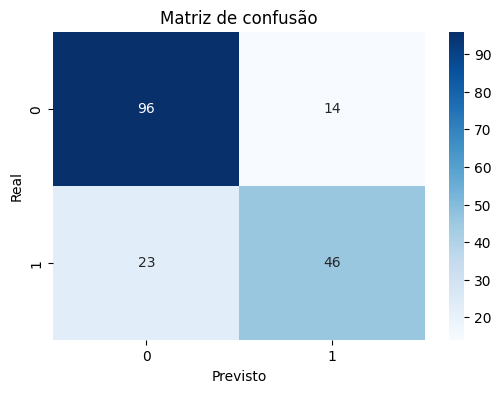

In [267]:
modelo_rf = RandomForestClassifier(
    n_estimators = 20,
    max_depth = 12,
    random_state = 42,
    n_jobs = -1
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_val)
y_pred_treino = modelo_rf.predict(X_train)

print("---- Relatório do modelo ----")
print(classification_report(y_val, y_pred_rf))

cm = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão')

plt.show()

In [268]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,34.5,0,0,7.8292,8.0,1.0
1,3,female,47.0,1,0,7.0000,8.0,2.0
2,2,male,62.0,0,0,9.6875,8.0,1.0
3,3,male,27.0,0,0,8.6625,8.0,2.0
4,3,female,22.0,1,1,12.2875,8.0,2.0


In [270]:
df_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [271]:
colunas_features = X_train.columns
X_test = df_test[colunas_features]

In [272]:
X_completo = pd.concat([X_train, X_val], axis=0)
y_completo = pd.concat([y_train, y_val], axis=0)

modelo_final = RandomForestClassifier(
    n_estimators=20,
    max_depth=12,
    random_state=42,
)

modelo_final.fit(X_completo, y_completo)


RandomForestClassifier(max_depth=12, n_estimators=20, random_state=42)

In [273]:
predicoes_finais = modelo_final.predict(X_test)

In [274]:
passenger_ids = pd.read_csv('test.csv')['PassengerId']

df_submissao = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predicoes_finais
})

df_submissao.to_csv('submission.csv', index=False)

print("Pronto! Arquivo 'submission.csv' gerado e pronto para envio.")

Pronto! Arquivo 'submission.csv' gerado e pronto para envio.


In [275]:
df_submissao.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
